In [3]:
from datetime import date
today = date.today().strftime("%Y%m%d")

import csv
import gzip
import itertools
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy.io

import click

import os
import glob

import pandas as pd 
import seaborn as sb
from collections import Counter, defaultdict

from itertools import compress
from itertools import combinations
import multiprocessing as mp
import pickle 
import sys

In [4]:
def write_new_matrix(data, cell, tags):
    ce = list(set(cell))
    ta = list(set(tags))
    m = scipy.sparse.dok_matrix((len(ce), len(ta)), dtype=np.int32)
    b2i = {b: i for i, b in enumerate(ce)}
    t2j = {t: j for j, t in enumerate(ta)}

    for n, i in enumerate(data):
        m[b2i[cell[n]], t2j[tags[n]]] = i

    m = m.tocsr()

    return m, ce, ta

def write_matrix(upb, cells, tags):
    m = scipy.sparse.dok_matrix((len(cells), len(tags)), dtype=np.int32)
    b2i = {b: i for i, b in enumerate(cells)}
    t2j = {t: j for j, t in enumerate(tags)}

    for b, bd in upb.items():
        for t, v in bd.items():
            m[b2i[b], t2j[t]] = v

    m = m.tocsr()

    return m
def write_matrix_1(upb, cells, tags):
    m = scipy.sparse.dok_matrix((len(cells), len(tags)), dtype=np.int32)
    b2i = {b: i for i, b in enumerate(cells)}
    t2j = {t: j for j, t in enumerate(tags)}

    for b, bd in upb.items():
        for t, v in bd.items():
            m[b2i[b], t2j[t]] = 1

    m = m.tocsr()

    return m
def write_matrix_lists(data, cells, tags, cells_list, tags_list):
    m = scipy.sparse.dok_matrix((len(cells_list), len(tags_list)), dtype=np.int32)

    for i,j,k in zip(data,cells,tags):
        m[j,k] = i

    m = m.tocsr()

    return m
def initial_h_set(barcodes):
    base_d = {"A": 1, "C": 2, "G": 3, "T": 4, "N": 5}

    return [int(''.join(map(str,tuple(base_d[c] for c in barcode)))) for barcode in barcodes]

def sub_group_10x(list_group_name,list_bcs,query_group):
    t_start=list_group_name.index(query_group)
    t_last=len(list_group_name)-list_group_name[::-1].index(query_group)
    subbed_group=list_bcs[t_start:t_last]
    
    return subbed_group
def intersection_check(cellnum1, query1, cellnum2, query2):
    int_val=len(set(cellnum1[list(set(query1))]).intersection(set(cellnum2[list(set(query2))])))
    return int_val
def intersection_check_3(cellnum1, query1, cellnum2, query2,cellnum3, query3):
    int_val=len(set(cellnum1[list(set(query1))]).intersection(set(cellnum2[list(set(query2))])).intersection(set(cellnum3[list(set(query3))])))
    return int_val
def intersection_check_slideseq_snseq(slideseq_tags, cellnum2, query2):
    a=set(slideseq_tags).intersection(set(cellnum2[list(set(query2))]))
    int_val=len(a)
    return int_val
def intersection_check_slideseq_snseq_val(slideseq_tags, cellnum2, query2):
    a=set(slideseq_tags).intersection(set(cellnum2[list(set(query2))]))
    return list(a)
def read_filt_process(u_in, u_idx, thresh, bc_in, tags_2):
    
    temp_data=u_in.data[u_idx]
    temp_cell=u_in.nonzero()[0][u_idx]
    temp_tags=u_in.nonzero()[1][u_idx]
    
    u2_whitelist_data_filt=temp_data[temp_data >= thresh]
    u2_whitelist_cell_filt=temp_cell[temp_data >= thresh]
    u2_whitelist_tags_filt=temp_tags[temp_data >= thresh]

    cells_by_tag_2=defaultdict(lambda: defaultdict(set))
    
    for idx1, idx2,val in zip(u2_whitelist_cell_filt,u2_whitelist_tags_filt,u2_whitelist_data_filt):
        cells_by_tag_2[bc_in[idx1]][tags_2[idx2]].add(val)
    cells_by_tag_2 = {
            bead_bc: {dtag: len(v) for dtag, v in dtags_per_bead.items()}
            for bead_bc, dtags_per_bead in cells_by_tag_2.items()
        }
    
    cells_new_2 = sorted(cells_by_tag_2)
    tags_new_2 = sorted({t for b in cells_new_2 for t in cells_by_tag_2[b]})
    
    return u2_whitelist_data_filt, u2_whitelist_cell_filt, u2_whitelist_tags_filt, cells_by_tag_2, cells_new_2, tags_new_2

def load_10x_tags(cur_nm, parent_dir):
    do_vars={}
    input_dir = parent_dir+"/{}/".format(cur_nm)
    
    with gzip.open(input_dir+"raw_umi_matrix.mtx.gz", "rb") as fh:
        m = scipy.io.mmread(fh).tocsr()
    with gzip.open(input_dir+"raw_tags.txt.gz", "rt") as fh:
        tags = [line.strip() for line in fh]
    with gzip.open(input_dir+"cells.txt.gz", "rt") as fh:
        cells = [line.strip() for line in fh]
        #cells = [ci[:-] for ci in cells]
    with gzip.open(input_dir+"raw_umi_matrix_umi.mtx.gz", "rb") as fh:
        u = scipy.io.mmread(fh).tocsr()
    with gzip.open(input_dir+"cells_umi.txt.gz", "rt") as fh:
        cells_u = [line.strip() for line in fh]
    do_vars["m"]=m
    do_vars["tags"]=tags
    do_vars["cells"]=cells
    do_vars["u"]=u
    do_vars["cells_u"]=cells_u
    
    return do_vars

# takes in library takes the max col for each row
# ie.) keeps only the tag with the highest read support and returns the new rows, cols, and data
def readFilt_10xStrat(library):
    # Assign only the tag with max read support to given umi
    cell_argmax=[i[0] for i in library['u'].argmax(axis=1).tolist()]
    
    new_rows=[i for i in range(library['u'].shape[0])]
    new_cols=cell_argmax
    new_data=[library['u'][i,j] for i,j in zip(new_rows,new_cols)]
    
    return new_rows, new_cols, new_data

def uTOm_readFilter(u_in, thresh, bc_in, tags_2):
    
    out_dict={}
    
    temp_data=u_in.data
    temp_cell=u_in.nonzero()[0]
    temp_tags=u_in.nonzero()[1]
    
    u2_whitelist_data_filt=temp_data[temp_data > thresh]
    u2_whitelist_cell_filt=temp_cell[temp_data > thresh]
    u2_whitelist_tags_filt=temp_tags[temp_data > thresh]

    cells_by_tag_2=defaultdict(lambda: defaultdict(set))
    
    for idx1, idx2,val in zip(u2_whitelist_cell_filt,u2_whitelist_tags_filt,u2_whitelist_data_filt):
        cells_by_tag_2[bc_in[idx1][:16]][tags_2[idx2]].add(bc_in[idx1][16:])
    
    cells_by_tag_2 = {
        bead_bc: {tag: len(v) for tag, v in tags_per_bead.items()}
        for bead_bc, tags_per_bead in cells_by_tag_2.items()
    }
    cells_new_2 = sorted(cells_by_tag_2)
    tags_new_2 = sorted({t for b in cells_new_2 for t in cells_by_tag_2[b]})
    
    # 
    out_dict["u_data_readFilt"]=u2_whitelist_data_filt
    out_dict["u_cell_readFilt"]=u2_whitelist_cell_filt
    out_dict["u_tags_readFilt"]=u2_whitelist_tags_filt
    out_dict["uRF"]=write_matrix(cells_by_tag_2, cells_new_2, tags_new_2)
    out_dict["cell_uRF"]=cells_new_2
    out_dict["tags_uRF"]=tags_new_2
    
    return out_dict



In [10]:
# parent_dir="/home/jsilverm/06_synapseseq_repo/data/Goofy_full/240215_Goofy/snrna/dialout"
parent_dir="/home/jsilverm/06_synapseseq_repo/data/Mickey_full/230630_Mickey/snrna_072623"
target_datasets=["Mickey_A"
                    ]
output_dir="/home/jsilverm/06_synapseseq_repo/data/outs/testing_10xFilter"
# target_datasets=["Goofy_A1", "Goofy_A2", "Goofy_B1",
#                   "Goofy_B2", "Goofy_C1", "Goofy_C2",
#                     "Goofy_D1", "Goofy_D2", "Goofy_E1",
#                     "Goofy_E2", "Goofy_F1", "Goofy_F2",
#                     "Goofy_G1", "Goofy_G2", "Goofy_H1",
#                     "Goofy_H2", "Goofy_I1", "Goofy_I2",
#                     "Goofy_J1", "Goofy_J2", "Goofy_K1",
#                     "Goofy_L1", "Goofy_L2"
#                     ]
custom_prefix=1
cluster_identity_dir="/home/jsilverm/06_synapseseq_repo/data/Mickey_full/230630_Mickey/snrna_cell_identity/Leaves2"
# cluster_identity_dir="/home/jsilverm/06_synapseseq_repo/data/Goofy_full/240215_Goofy/snrna/library/240319_celltypes"
custom_cluster=-10
perc_cutoff_list=[0.1, 0.2, 0.4]

In [11]:
try:
    os.mkdir(output_dir)
except:
    print('Output path already exists - continuing')

print("Processing data")
if custom_prefix > -1:
    name_prefix = [i.split('_')[custom_prefix] for i in target_datasets]
else:
    name_prefix = ["S"+i.split('_')[1] for i in target_datasets]
prefix_2_dataset = {i:j for i,j in zip(name_prefix, target_datasets)}

print(name_prefix)

# read in barcode extraction results for each dataset. Cells x tags and tagsxreads matrices
all_libraries_raw = {i:load_10x_tags(i, parent_dir) for i in target_datasets}

check_cellLen=len(all_libraries_raw[target_datasets[0]]['cells'][0])
if check_cellLen != 16:
    sys.exit(f'Cell length is incorrect (Expected: 16, Observed: {check_cellLen}')
else:
    print(f"{all_libraries_raw[target_datasets[0]]['cells'][0]} - Length: {check_cellLen}")


Output path already exists - continuing
Processing data
['A']
AAAAAAAAACCCCCCC - Length: 16


In [17]:
"AGATCTACGGGTGGCATCCCTGTGACCCCTCC" in set(all_libraries_raw["Mickey_A"]["tags"])

False

In [7]:
print(len(all_libraries_raw["Goofy_A1"]["u"].data))

2214751


In [22]:
for i in target_datasets:
    all_libraries_raw[i]["cells_INT"]=np.asarray(initial_h_set(all_libraries_raw[i]["cells"]))
    # take the inx for the cell which the tag has the highest value
    # all_libraries_raw[i]["m_maxTags"]=np.asarray(all_libraries_raw[i]["m"].argmax(axis=0))[0]
    # split cell bc and umi for the umi/reads matrix
    all_libraries_raw[i]["cells_u_bc"]=[j[:16] for j in all_libraries_raw[i]["cells_u"]]
    all_libraries_raw[i]["cells_u_umi"]=[j[16:] for j in all_libraries_raw[i]["cells_u"]]
    all_libraries_raw[i]["cells_INT"]=np.asarray(initial_h_set(all_libraries_raw[i]["cells"]))
    all_libraries_raw[i]["cells_u_bc_INT"]=np.asarray(initial_h_set(all_libraries_raw[i]["cells_u_bc"]))    


In [23]:
for i in target_datasets:
    new_rows, new_cols, new_data = readFilt_10xStrat(all_libraries_raw[i])
    all_libraries_raw[i]['u_10xFilt'] = write_matrix_lists(new_data, new_rows, new_cols, all_libraries_raw[i]['cells_u'], all_libraries_raw[i]['tags'])


In [145]:
def run_row_u_parsing(row, tag_ids, current_row_inx):
    nonzero_indices = row.nonzero()[1]
    nonzero_tags = [tag_ids[i] for i in nonzero_indices]
    nonzero_vals = [row[0,i] for i in nonzero_indices]
    r = {"row_inx": current_row_inx, "nonzero_tags": nonzero_tags, "nonzero_vals": nonzero_vals}
    return r

def run_row_parsing_from_u(u_mat, tag_ids, cell_umi_ids):
    args = [(u_mat.getrow(i), tag_ids, i) for i in range(u_mat.shape[0])]
    n_cores = 20
    pool = mp.Pool(n_cores)
    results = pool.starmap(run_row_u_parsing, args)
    pool.close()

    results_w_cell_name = []
    for i, r in enumerate(results):
        r["cell_name"] = cell_umi_ids[i]
        results_w_cell_name.append(r)

    return results_w_cell_name


def do_hamming_compare(current_result):
    len_tags = len(current_result["nonzero_tags"][0])
    tags = current_result["nonzero_tags"]
    hamming_dists = []
    if len(tags) > 1:
        for i in range(len(tags)):
            for j in range(i+1, len(tags)):
                hamming_dists.append(scipy.spatial.distance.hamming(list(tags[i]), list(tags[j])) * len_tags)
    hamming_dists = np.array(hamming_dists)
    r = {"row_inx": current_result["row_inx"], "hamming_dists": hamming_dists}
    return r

def check_hamming_results(cellbc_umi_results, n_cores=20):
    args_tup = [(i,) for i in cellbc_umi_results]
    pool = mp.Pool(n_cores)
    results_hamming = pool.starmap(do_hamming_compare, args_tup)
    pool.close()
    # add all hamming distances to a list
    hamming_dists = []
    for i in results_hamming:
        hamming_dists.extend(i["hamming_dists"])
    return hamming_dists


def do_basic_hamming(seq1, seq2):
    size = len(seq1)
    hamming = scipy.spatial.distance.hamming(list(seq1), list(seq2)) * size
    return hamming



def get_hamming_null(tags_list, n_comparisons, n_cores=20):
    n_tags = len(tags_list)
    # create n_comparisons where 2 random but not equal numbers between 0 and n_tags are selected
    random_tag_pairs = np.random.choice(n_tags, (n_comparisons, 2), replace=True)

    args = [(tags_list[i], tags_list[j]) for i,j in random_tag_pairs]
    pool = mp.Pool(n_cores)
    results = pool.starmap(do_basic_hamming, args)
    pool.close()
    return results


In [148]:
u_mat_a1 = all_libraries_raw["Goofy_A1"]["u"]
u_filt_a1 = all_libraries_raw["Goofy_A1"]["u_10xFilt"]

tag_ids = all_libraries_raw["Goofy_A1"]["tags"]
cell_ids = all_libraries_raw["Goofy_A1"]["cells_u"]
# descriptive statistics for tags appearing per cell

def parse_raw_umat_for_descrip(u_mat, tag_ids, cell_ids):
    results_w_cell_name = run_row_parsing_from_u(u_mat, tag_ids, cell_ids)
    tags_per_cell = [len(i["nonzero_tags"]) for i in results_w_cell_name]
    hamming_dists = check_hamming_results(results_w_cell_name, n_cores=20)
    return results_w_cell_name, tags_per_cell, hamming_dists 


results_1, tags_per_cell_1, hamming_dists_1 = parse_raw_umat_for_descrip(u_mat_a1, tag_ids, cell_ids)



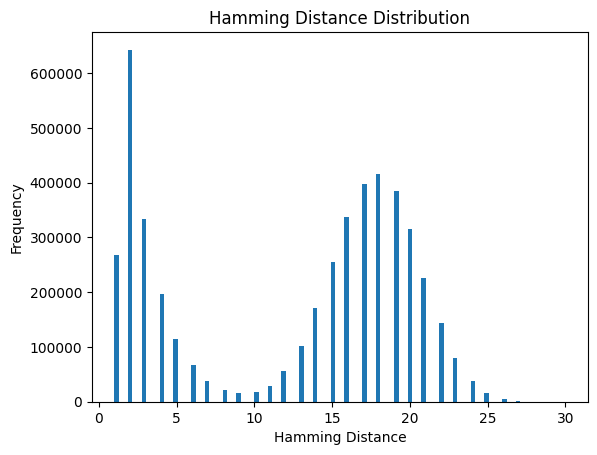

In [147]:

# plot the distribution of hamming distances
plt.hist(hamming_dists, bins=100)
plt.xlabel("Hamming Distance")
plt.ylabel("Frequency")
plt.title("Hamming Distance Distribution")
plt.show()


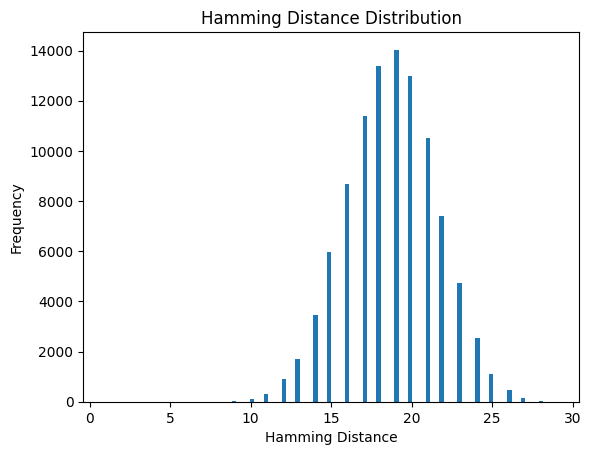

In [140]:


n_comparisons = 100000
n_tags = len(tags_list)
# create n_comparisons where 2 random but not equal numbers between 0 and n_tags are selected
random_tag_pairs = np.random.choice(n_tags, (n_comparisons, 2), replace=True)

args = [(tags_list[i], tags_list[j]) for i,j in random_tag_pairs]
pool = mp.Pool(n_cores)
results = pool.starmap(do_basic_hamming, args)
pool.close()

plt.hist(results, bins=100)
plt.xlabel("Hamming Distance")
plt.ylabel("Frequency")
plt.title("Hamming Distance Distribution")
plt.show()


In [141]:
np.min(results)

1.0

In [116]:
n_tags_per_cell = [len(i["nonzero_tags"]) for i in results]

Max: 11, Median: 1.0, Mean: 1.8347568178095066
Proportion of cells with 1 tag: 0.654313994292267


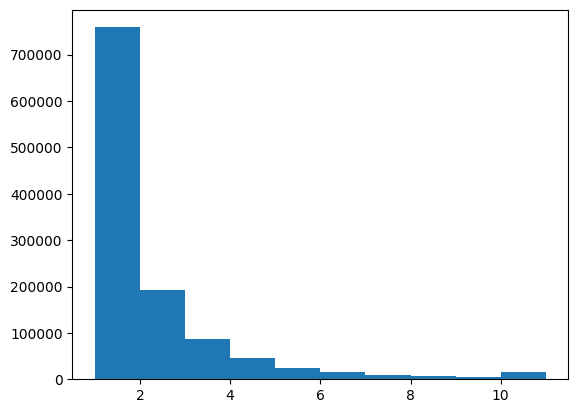

In [121]:
max = np.max(n_tags_per_cell)
median = np.median(n_tags_per_cell)
mean = np.mean(n_tags_per_cell)
proportion_eq1 = n_tags_per_cell.count(1)/len(n_tags_per_cell)

print(f"Max: {max}, Median: {median}, Mean: {mean}")
print(f"Proportion of umi with 1 tag: {proportion_eq1}")
# if val is > 10 set to 10
n_tags_per_cell = [i if i <= 10 else 11 for i in n_tags_per_cell]

plt.hist(n_tags_per_cell)
# limit x axis to 1-10
plt.show()

In [151]:
### AAV Library Results ###
ember1_path = "/home/jsilverm/06_synapseseq_repo/data/aav/EmberPlus_2_aav_lib/ember_1_overlap_counts.csv"
ember2_path = "/home/jsilverm/06_synapseseq_repo/data/aav/EmberPlus_2_aav_lib/ember_2_overlap_counts.csv"

ember1 = pd.read_csv(ember1_path, header=None)
ember2 = pd.read_csv(ember2_path, header=None)

In [156]:
all_tags_path = "/home/jsilverm/06_synapseseq_repo/data/aav/EmberPlus_2_aav_lib/aav_123_overlap_tags.txt.gz"
all_tags = []
with gzip.open(all_tags_path, "rt") as fh:
    for line in fh:
        all_tags.append(line.strip())
all_tags_set = set(all_tags)

In [162]:
len(all_tags)

11353006

In [161]:
is_in_set = [i in all_tags_set for i in tag_ids]
np.unique(is_in_set, return_counts=True)

(array([False,  True]), array([521331,  73434]))